<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src=attachment:ad91936b-ffaa-4d78-8fca-1b445a35e3cd.jpg alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---

# <h1><center>Interrogación 2</center></h1>

## Instrucciones

* Esta parte de la Interrogación debe ser desarrollada completamente en lenguaje de programación Python en este Notebook de Jupyter.

* El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados, y siguiendo buenas prácticas de programación. <br>
* La entrega de la interrogación se realizará a través de Canvas en la actividad `I2 Desarrollo`.
* Esta Interrogación debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
* Está **estrictamente prohibido comunicarse con sus compañeros de curso, terceras personas o uso de IA** durante el desarrollo de esta interrogación.
* Puede consultar los apuntes del curso y soluciones disponibles en el repositorio del ramo.
* Habrá sólo dos instancias para hacer preguntas, una al inicio de la prueba y otra a los 30 minutos de avance.<br>


* Ud. dispone de 1 hora para desarrollar esta interrogación.
* Recuerde **guardar frecuentemente sus avances** para evitar pérdidas de trabajo o problemas de envío.<br>
---

## Parte 2: Trabajo de Desarrollo (60 min)

Esta parte de la Interrogación es un trabajo práctico con datos. En esta parte, cada pregunta debe ser respondida desarrollando un código por usted que le permita entregar una respuesta.

En esta sección, estaremos trabajando con dos bases de datos. En primer lugar, usaremos los registros de la Organización Mundial de la Salud (OMS) de las espectativas de vida en distintos países a través de los años (Disponible desde la [página web de la OMS](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/life-expectancy-at-birth-(years))) En segundo lugar, utilizaremos los datos de producto interno bruto (PIB) de distintos países (Disponible desde [Kaggle](https://www.kaggle.com/datasets/codebynadiia/gdp-per-country-20202025)).

Nuestro objetivo será explorar y analizar el comportamiento de estos datos, comprendiendo la relación entre estas dos variables, para finalmente entrenar modelos de regresión y evaluar su desempeño.

## 1. Lectura, limpieza y transformación (20 pts)

### 1.1 Lectura e inspección inicial (5 pts)
Usted dispone de los siguientes archivos:
* `pib2020-2025.csv`: contiene información del PIB en mil millones de USD de varios países entre los años 2020 y 2025.
* `WHO_life_expectancy.csv`: dataset de la OMS que contiene información sobre la espectativa de vida en varios países y años.

Para comenzar, cargue los dos archivos en dos dataframes separados llamados `pib_df`y `life_df`, respectivamente. Para cada uno, imprima la cantidad de filas que tiene, las columnas y sus tipos, y las primeras 5 filas.

In [29]:
# agregue las librerías que crea necesarios. Acá dejamos algunas estánadar que podrían ser de ayuda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join

In [30]:
# respuestas
#dataframe para el archivo PIB
path_pib = join('data', 'pib2020-2025.csv')
pib_df = pd.read_csv(path_pib)

path_life_exp = join('data', 'WHO_life_expectancy.csv')
life_df = pd.read_csv(path_life_exp)

print("Dataframes creados y sus primeras 5 filas:")
display(pib_df.head(5))
display(life_df.head(5))

Dataframes creados y sus primeras 5 filas:


,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [31]:
print("="*15 + " Información y columnas de PIB: " + "="*15)
display(pib_df.info())
display(pib_df.columns)
print(f"pib_df tiene {len(pib_df)} entradas")
print("="*53 + "\n")

print("="*10 + " Información de Life Expentacy: " + "="*11)
display(life_df.info())
display(life_df.columns)
print(f"life_df tiene {len(life_df)} entradas")
print("="*53 + "\n")

=============== Información y columnas de PIB: ===============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


None

Index(['Country', '2020', '2021', '2022', '2023', '2024', '2025'], dtype='object')

pib_df tiene 196 entradas

========== Información de Life Expentacy: ===========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-null  object
 6   Location             24420 non-null  object
 7   Period type          24420 non-null  object
 8   Period               24420 non-null  int64 
 9   Dim1 type            24420 non-null  object
 10  Dim1                 24420 non-null  object
 11  Value                24420 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.2+ MB


None

Index(['IndicatorCode', 'Indicator', 'ParentLocationCode', 'ParentLocation',
       'Location type', 'SpatialDimValueCode', 'Location', 'Period type',
       'Period', 'Dim1 type', 'Dim1', 'Value'],
      dtype='object')

life_df tiene 24420 entradas



### 1.2 Limpieza de datos PIB (5 pts)

* Asegúrese de que su DataFrame `pib_df` no contenga valores nulos.
* Identifique si hay datos duplicados y elimínelos.
* Corrija los tipos de las columnas según corresponda, siempre justificando sus decisiones.

In [32]:
# respuestas, identificamos los nulos de cada df
nulos_pib = pib_df.isna().sum()
nulos_life = life_df.isna().sum()
display(nulos_pib, nulos_life)

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

IndicatorCode          0
Indicator              0
ParentLocationCode     0
ParentLocation         0
Location type          0
SpatialDimValueCode    0
Location               0
Period type            0
Period                 0
Dim1 type              0
Dim1                   0
Value                  0
dtype: int64

In [33]:
display(pib_df.duplicated().sum())
display(life_df.duplicated().sum())
print("no hay entradas duplicadas")

np.int64(0)

np.int64(0)

no hay entradas duplicadas


In [34]:
#como solo hay nulos en pib_df, los vemos y eliminamos:
display(pib_df[pib_df.isna().any(axis=1)])

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
54,Eritrea,1982,NaN,NaN,NaN,NaN,NaN
96,Lebanon,24976,19782.0,24748.0,23607.0,28280.0,NaN
131,Pakistan,300410,348481.0,374850.0,337754.0,373078.0,NaN
161,Sri Lanka,84304,88609.0,74584.0,83723.0,98964.0,NaN
169,Syria,60043,NaN,NaN,NaN,NaN,NaN
192,Palestine,15532,18109.0,19166.0,17848.0,NaN,NaN


In [35]:
#eliminar pendiente dame un comando para borar las filas que contengan nulos de pib_df
pib_df = pib_df.dropna()
print("nulos actuales:")

nulos_pib2 = pib_df.isna().sum()
display(nulos_pib2)

nulos actuales:


Country    0
2020       0
2021       0
2022       0
2023       0
2024       0
2025       0
dtype: int64

In [51]:
#para visualixar los contenidoss
display(pib_df.sample(3), life_df.sample(3))

,Country,2020,2021,2022,2023,2024,2025
118,Mozambique,14235,16168.0,18884.0,20954.0,21944.0,23771.0
152,Sierra Leone,6682,7165.0,7119.0,6397.0,7653.0,8386.0
155,Slovenia,53342,61570.0,59975.0,69168.0,72463.0,75224.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
7095,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,HUN,Hungary,Year,2015,Sex,Female,78.8 [78.7-78.9]
23689,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,DZA,Algeria,Year,2000,Sex,Female,73.8 [73.4-74.2]
5106,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,GHA,Ghana,Year,2017,Sex,Both sexes,16.7 [16.2-17.3]


In [47]:
pib_df.dtypes

Country     object
2020         int64
2021       float64
2022       float64
2023       float64
2024       float64
2025       float64
dtype: object

In [48]:
life_df.dtypes

IndicatorCode          object
Indicator              object
ParentLocationCode     object
ParentLocation         object
Location type          object
SpatialDimValueCode    object
Location               object
Period type            object
Period                  int64
Dim1 type              object
Dim1                   object
Value                  object
dtype: object

In [52]:
object_cols = life_df.select_dtypes(include='object').columns

print("Columna (Tipo 'object')   | Número de Valores Únicos")
print('-'*52)
for col in object_cols:
    # .nunique() -> CONTEO
    num_unique = life_df[col].nunique()

    # ":<25" es solo formato para alinear el texto
    print(f"{col:<25} | {num_unique}")
print('-'*52)

Columna (Tipo 'object')   | Número de Valores Únicos
----------------------------------------------------
IndicatorCode             | 2
Indicator                 | 2
ParentLocationCode        | 6
ParentLocation            | 6
Location type             | 1
SpatialDimValueCode       | 185
Location                  | 185
Period type               | 1
Dim1 type                 | 1
Dim1                      | 3
Value                     | 9937
----------------------------------------------------


Las columnas `IndicatorCode`, `Indicator`, `ParentLocationCode`, `ParentLocation`, `Location type`, `Period type`, `Dim1 type` y `Dim1` son perfectas para llevarlas a **type=category** dado que contienne muy pocas entradas distintas de sí mísmas y así reducimos espacio en memoria.

Por lo que llevaremos dichas columnas a categoría.


In [54]:
# Lista de columnas que quieres convertir
l_cols = [
    'IndicatorCode', 
    'Indicator', 
    'ParentLocationCode', 
    'ParentLocation', 
    'Location type', 
    'Period type', 
    'Dim1 type', 
    'Dim1'
]

# Itera sobre la lista y convierte cada columna a 'category'
for col in l_cols:
    life_df[col] = life_df[col].astype('category')
life_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   IndicatorCode        24420 non-null  category
 1   Indicator            24420 non-null  category
 2   ParentLocationCode   24420 non-null  category
 3   ParentLocation       24420 non-null  category
 4   Location type        24420 non-null  category
 5   SpatialDimValueCode  24420 non-null  object  
 6   Location             24420 non-null  object  
 7   Period type          24420 non-null  category
 8   Period               24420 non-null  int64   
 9   Dim1 type            24420 non-null  category
 10  Dim1                 24420 non-null  category
 11  Value                24420 non-null  object  
dtypes: category(8), int64(1), object(3)
memory usage: 955.2+ KB


Notemos como disminuyo la memoria dado que llevamos columnas a categorias

### 1.3 Filtrar datos de `life_df` (5 pts)

Esta vez, solo usaremos los valores de **espectativa de vida al nacer** para cada país según sexo.
Inspeccione su DataFrame y realice los siguientes pasos:

1. Elimine todas las filas que no correspondan a espectativas de vida al nacer.
2. Elimine todas las columnas que considere innecesarias. Justifique su elección.

In [ ]:
# respuestas, mantengo las que SI pertenecen a espectativa de vida al nacer
filtro_indicador = 'Life expectancy at birth (years)'

life_df = life_df[life_df['Indicator'] == filtro_indicador]

life_df.head()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [61]:
#eliminamos las columnas:
columnas_a_eliminar = [
    'Period type', 
    'SpatialDimValueCode', 
    'IndicatorCode'
]

life_df = life_df.drop(columns=columnas_a_eliminar)

# Si prefieres modificar el DataFrame original (inplace):
# life_df.drop(columns=columnas_a_eliminar, inplace=True)
life_df.columns

Index(['Indicator', 'ParentLocationCode', 'ParentLocation', 'Location type',
       'Location', 'Period', 'Dim1 type', 'Dim1', 'Value'],
      dtype='object')

Se liminan estas columans porque no cumplen un rol fundamental según lo estipulado en el enunciado. Como contienen datos un tanto redundantes no serán de aporte en este análisis.

### 1.4 Transformar valores de `life_df` (5 pts)

Podrá haber notado que la columna `Value` es un string de formato `n1 [n2-n3]`, donde `n1` es el valor promedio de la variable, mientras que `n2`y `n3` son los límites inferior y superior de la variable. Para nuestro análisis, solo nos interesa el valor promedio.

* Transforme la columna `Value` para que solo contenga el valor promedio (`n1`). Asegúrese de que el tipo de columna sea siempre el correcto.
* Imprima los estadísticos principales de esta columna (promedio, desviación estándar, mínimo y máximo, etc)


In [ ]:
# respuestas, limpiamos life_expentacy
life_df['Value'] = life_df['Value'].str.split(' ').str[0]
display(life_df.head(1))
display(life_df.dtypes)

,Indicator,ParentLocationCode,ParentLocation,Location type,Location,Period,Dim1 type,Dim1,Value
0,Life expectancy at birth (years),AFR,Africa,Country,Lesotho,2021,Sex,Male,48.7


Indicator             category
ParentLocationCode    category
ParentLocation        category
Location type         category
Location                object
Period                   int64
Dim1 type             category
Dim1                  category
Value                   object
dtype: object

Como `Value` sigue en objtect, la pasamos a `float`

In [ ]:
life_df['Value'] = life_df['Value'].astype(float) #esto para obtener las medidas estadisticas
display(life_df.dtypes)
print("Medidas estadísticas de life_df:")
display(life_df['Value'].describe())

Indicator             category
ParentLocationCode    category
ParentLocation        category
Location type         category
Location                object
Period                   int64
Dim1 type             category
Dim1                  category
Value                  float64
dtype: object

Medidas estadísticas de life_df:


count    12210.000000
mean        70.174914
std          8.899653
min         36.600000
25%         64.200000
50%         71.900000
75%         77.100000
max         87.400000
Name: Value, dtype: float64

## 2. EDA univariado (27 pts)

Procederemos a explorar los datos contenidos dentro de `pib_df` y `life_df` por separado. Responda las siguientes preguntas, apoyándose de un gráfico cuando se le indique. No olvide colocar un título claro y etiquetas a los ejes de sus gráficos.

### 2.1 Valores del PIB (12 pts)

* a ¿Entre qué magnitudes de valores se mueve el PIB de los países del mundo desde el año 2020 hasta 2025?
* b ¿Cuáles son los 3 países con mayor PIB en 2025? CHECK
* c ¿Cuáles son los 3 países con menor PIB en 2021?
* d Seleccione un año de los disponibles y realice un histograma de los valores del PIB para ese año. ¿Cómo se distribuye esta variable? Comente.

In [73]:
year_cols = ['2020', '2021', '2022', '2023', '2024', '2025']

# Calculamos el valor mínimo y máximo en todo el rango de años
min_pib = pib_df[year_cols].min().min()
max_pib = pib_df[year_cols].max().max()
print(f"El PIB (2020-2025) se mueve entre {min_pib} y {max_pib} (miles de millones USD).")


El PIB (2020-2025) se mueve entre 52.0 y 30507217.0 (miles de millones USD).


In [ ]:
#Vamos a hacer un melt para poder asignar las columnas a graficar
df_pib_para_graficar = pib_df.melt(
    id_vars=['Country'],
    var_name='Year',        #Nombre para la nueva columna de "años"
    value_name='PIB'        #Nombre para la nueva columna de "valores" (PIB)
)

print("Dataframe df_pib_plot creado (primeras 5 filas)")
display(df_pib_para_graficar.sample(5).sort_index())

Dataframe df_pib_plot creado (primeras 5 filas)


,Country,Year,PIB
95,Liberia,2020,3037.0
119,Nepal,2020,33434.0
291,Malaysia,2021,373785.0
738,Trinidad and Tobago,2023,25489.0
916,Sudan,2024,28270.0


/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_9824/3736617048.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_por_ano = df_pib_para_graficar.groupby('Year').apply(


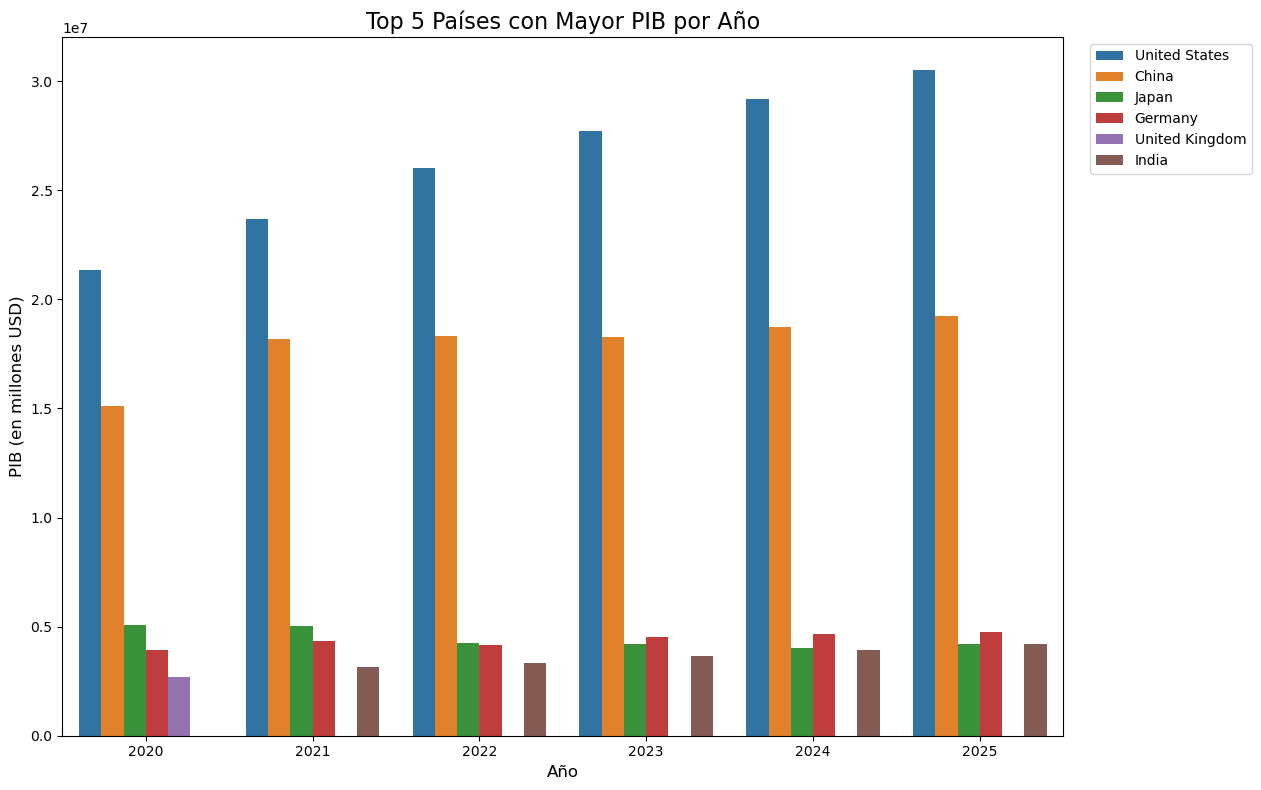

In [ ]:
# respuestas b:
df_pib_para_graficar = df_pib_para_graficar.dropna(subset=['PIB'])

# --- Paso 4: Encontrar el Top 5 POR AÑO (El paso más simple y clave) ---
# Agrupamos por 'Year'
# Para cada grupo (año), aplicamos una función (lambda) que toma el mayor PIB
# .reset_index(drop=True) limpia el índice para que Seaborn lo lea bien.
top_5_por_ano = df_pib_para_graficar.groupby('Year').apply(
    lambda x: x.nlargest(5, 'PIB')
).reset_index(drop=True) #nlargest arroja las n filas con los valores PIB más altos


# Gráfico de Barras Agrupadas
plt.figure(figsize=(15, 8))

sns.barplot(
    data=top_5_por_ano,
    x='Year',       # Años en el eje X
    y='PIB',        # PIB en el eje Y
    hue='Country'   # Barras de colores agrupadas por País
)

plt.title('Top 5 Países con Mayor PIB por Año', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('PIB (en millones USD)', fontsize=12)


# (1.02, 1) significa "un poco a la derecha y arriba del gráfico"
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Ajustar el layout para que la leyenda no se corte
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Deja espacio a la derecha (85% de ancho)

En relacion a los **PIB**, notamos que en 2025, el top 3 de los países con mayor PIB son:
1. EEUU
2. China
3. Alemania

In [ ]:
# respuestas 2.1c
bottom_3_2021 = pib_df.sort_values(by='2021', ascending=True).head(3)
print("\nLos 3 países con menor PIB en 2021 son:")
print(bottom_3_2021[['Country', '2021']])



Los 3 países con menor PIB en 2021 son:
    Country   2021
181  Tuvalu   62.0
121   Nauru  176.0
132   Palau  236.0


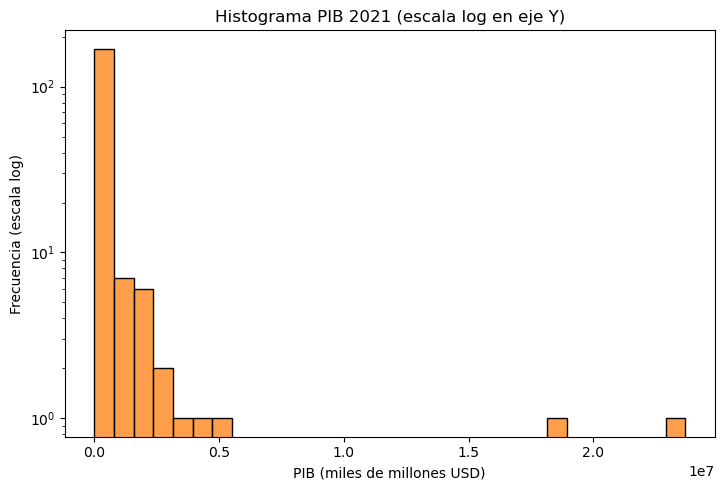

In [83]:
year = '2021'
data_year = pib_df[year].dropna()

plt.figure(figsize=(14,5))

plt.subplot(1,2,2)
sns.histplot(data_year, bins=30, kde=False, color='C1', edgecolor='black')
plt.yscale('log')
plt.title(f'Histograma PIB {year} (escala log en eje Y)')
plt.xlabel('PIB (miles de millones USD)')
plt.ylabel('Frecuencia (escala log)')

plt.tight_layout()
plt.show()

Aplicar la escala log es fundamental para una correcta visualizacion de datos

/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_12421/1375186290.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pib_para_graficar, x='Year', y='PIB', palette='viridis')


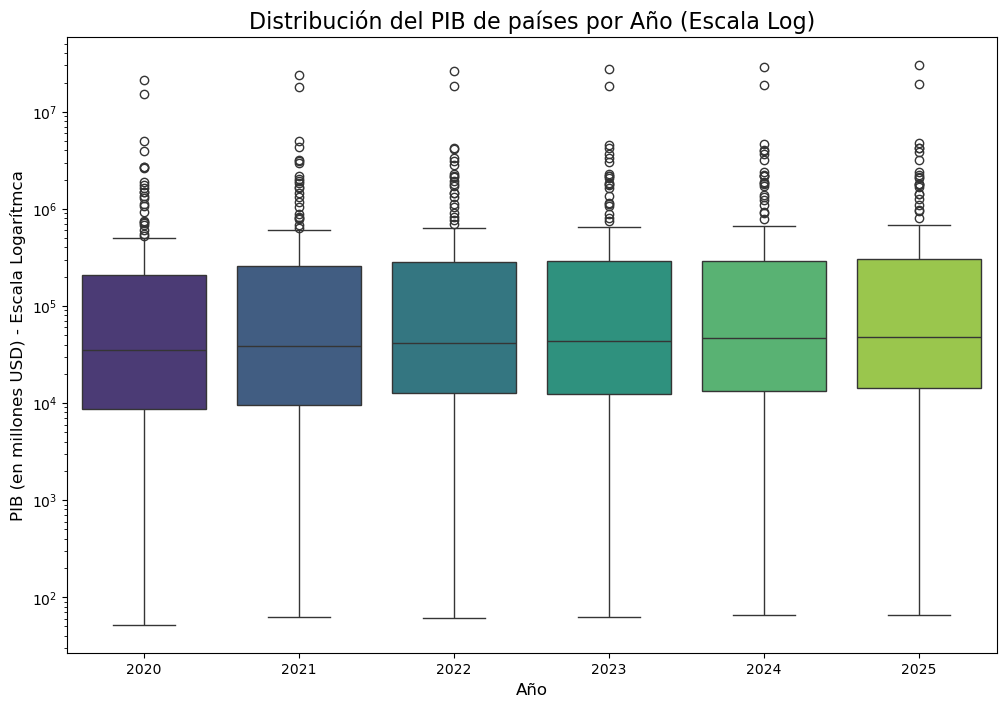

In [77]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_pib_para_graficar, x='Year', y='PIB', palette='viridis')

# Usamos una escala logarítmica para poder ver la distribución correcta, sin sesgos por outliers
plt.yscale('log')

plt.title('Distribución del PIB de países por Año (Escala Log)', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('PIB (en millones USD) - Escala Logarítmca', fontsize=12)

plt.show()

Notemos que existen varios outliers en cada año respectivo.

Notemos que aplicar una escala log es fundamemtal para tener una visualizacion de datos acorde.

Respuestas:

### 2.2 Esperanzas de vida (15 pts)

* a ¿Cuántos países distintos hay representados dentro de `life_df`?
* b ¿Cuál es el rango de años que contiene el dataset? ¿Cuáles de estos coinciden con los años que tenemos en `pib_df`?
*  c El dataset de la OMS le asigna un `ParentLocation` a cada país. Imprima todos los posibles valores y cuántas veces se repiten en su dataset `life_df`. ¿Cómo interpreta estas cantidades?
* d Realice un boxplot que muestre la esperanza de vida según sexo y continente (o sector `ParentLocation`). Puede realizar uno o dos gráficos. Realice esta visualización solamente con los datos de 2021.

In [ ]:
# respuestas 2.2 a
life_df['Location'].nunique()

185

hay 185 paises distintos identificados

Respuestas:

## 3. EDA multivariado (10 pts)

Ahora queremos entender la relación entre las variables del PIB y la esperanza de vida al nacer. Genere un único dataframe llamado `full_df` a partir de los dos datasets anteriores y responda las siguientes preguntas. De aquí en adelante, vamos a considerar **solamente** la esperanza de vida calculada para ambos sexos (Both sexes).

* ¿Cuál es la correlación entre el PIB de un país con la esperanza de vida al nacer? Calcule el valor para los años 2020 y 2021. ¿Qué nos indica este valor?

* Realice un scatterplot donde su eje X represente la esperanza de vida y su eje Y, el PIB. Comente lo que observa.

In [40]:
# respuestas

## 4. Transformación de escala (15 pts)

Ahora vamos a transformar la escala de nuestras variables para visualizar mejor la relación entre la espectativa de vida y PIB de los países.

* Genere las columnas `logPIB 2020` y `logPIB 2021`, donde el valor de cada columna corresponde al logaritmo en base 10 del PIB original. (Por ejemplo, si un valor de la columna `2020` es $x$, el valor correspondiente en la columna `logPIB 2020` debe ser $log_{10}(x)$

* Calcule nuevamente la correlación entre el PIB y la esperanza de vida al nacer para los dos años mencionados.

* Ahora, genere nuevamente un scatterplot entre la espectativa de vida promedio al nacer y su nueva representación del PIB para los años 2020 y 2021 por separado. ¿Puede ver alguna relación entre estas variables? Comente sus resultados.

In [41]:
# respuestas

## 5. Regresiones (28 pts)

Finalmente entrenaremos algunos modelos de regresión. Vamos a comparar el desempeño entre una regresión lineal y una **regresión logarítmica**, donde el valor a predecir ($y$), será calculado como:
$$ y = \beta_0 + \beta_1 \cdot log_{10}(X)$$

donde $X$ será nuestro PIB, $y$ corresponderá a la espectativa de vida al nacer y $\beta_0, \beta_1$ los coeficientes que calculará nuestro modelo.

En la práctica, vamos a partir realizando dos **regresión lineales**: la primera con la variable del PIB original y la segunda con nuestras nuevas columnas `logPIB` como nuestro $X$. 

En la siguiente sección, trabaje solamente con las esperanzas de vida de ambos sexos calculadas el año 2021.

In [42]:
# acá dejamos algunas librerías que pueden ser de utilidad, pero pueden agregar otras.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error as rmse
from sklearn.preprocessing import PolynomialFeatures

#### 5.1 Cree la matriz $X_1$ (PIB 2020 y 2021) y $X_2$ (log PIB 2020 y 2021), junto con el vector **y**. Luego separe cada uno en conjunto de entrenamiento y prueba con una división 70-30. (5 pts)
(Asigne explícitamente un valor a `random_state` para que su respuesta sea reproducible.)

In [43]:
# respuestas

#### 5.2 Entrene un modelo de regresión lineal para $X_1$. Imprima los coeficientes encontrados y calcule el RMSE y el $r^2$ para los conjuntos de entrenamiento y prueba. ¿Es una buena regresión? (10 pts)

In [44]:
# respuestas

Respuestas:

#### 5.3 Repita el proceso, esta vez para $X_2$. ¿Cómo se compara con la anterior? (6 pts)

In [45]:
# respuestas

Respuestas:

#### 5.4 Elija la variable con la que mejor desempeño obtuvo y entrene un modelo de regresión "polinomial" de grado 2, 3 y 4 con ella. Calcule nuevamente el RMSE y el $r^2$ para ambos conjuntos. ¿Mejoró su resultado? De todos los modelos, ¿cuál eligiría? (7 pts)

In [46]:
# respuestas

Respuestas: